In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv('gurgaon_properties_outliers_treated.csv')

In [7]:
df.isnull().sum()

society                   1
price                     0
sector                    0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1012
agePossession             0
property_type             0
super_built_up_area    1680
built_up_area          1968
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

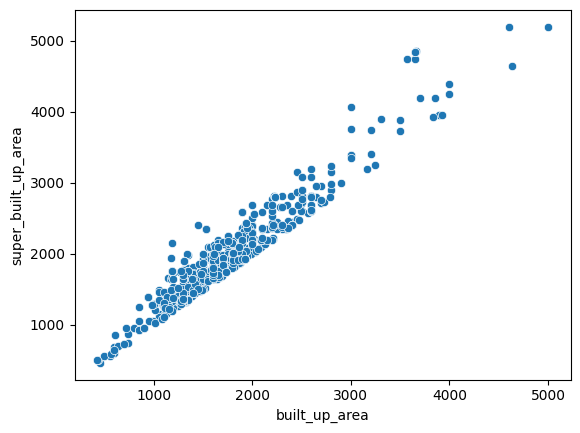

In [9]:
sns.scatterplot(x = df['built_up_area'], y = df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

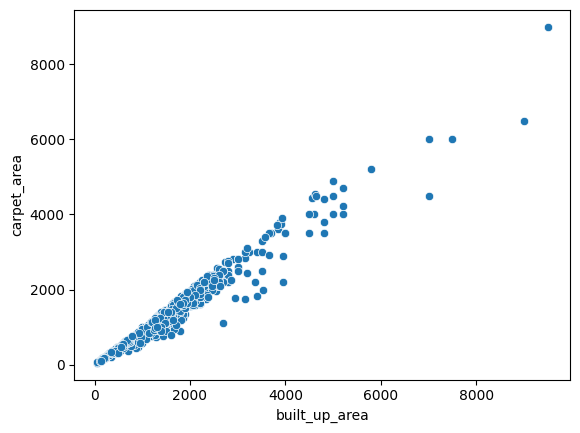

In [11]:
sns.scatterplot(x = df['built_up_area'],y = df['carpet_area'])

In [12]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

0       False
1       False
2       False
3       False
4       False
        ...  
3550    False
3551    False
3552    False
3553    False
3554    False
Length: 3555, dtype: bool

In [13]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [14]:
all_present_df.shape

(531, 24)

In [15]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [16]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [17]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [18]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [19]:
sbc_df.shape

(421, 24)

In [20]:
sbc_df['built_up_area'] = sbc_df['built_up_area'].fillna(
    (
        (
            (sbc_df['super_built_up_area'] / 1.105) +
            (sbc_df['carpet_area'] / 0.9)
        ) / 2
    ).round()
)

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_46564\2550114535.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbc_df['built_up_area'] = sbc_df['built_up_area'].fillna(


In [21]:
df.update(sbc_df)

In [22]:
df.isnull().sum()

society                   1
price                     0
sector                    0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1012
agePossession             0
property_type             0
super_built_up_area    1680
built_up_area          1547
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [23]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [24]:
sb_df.head()

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
4,emaar mgf the palm drive,3.98,sector 66,18090.0,2200.11,Super Built up area 2200(204.39 sq.m.),3,4,3+,2.0,South-East,Moderately Old,flat,2200.0,NaN,NaN,0,1,0,0,0,2,123,733.370000
8,m3m soulitude,1.25,sector 89,8784.0,1423.04,Super Built up area 1423(132.2 sq.m.),3,3,3,3.0,East,New Property,flat,1423.0,NaN,NaN,1,0,0,0,1,0,61,474.346667
15,tata gurgaon gateway,2.45,sector 113,10786.0,2271.46,Super Built up area 2225(206.71 sq.m.),3,3,3,8.0,North,Relatively New,flat,2225.0,NaN,NaN,0,0,0,0,0,0,110,757.153333
16,dlf new town heights,1.65,sector 91,6345.0,2600.47,Super Built up area 2364(219.62 sq.m.),4,4,3+,11.0,West,Moderately Old,flat,2364.0,NaN,NaN,0,1,0,0,0,0,72,650.117500
21,shapoorji pallonji joyville gurugram,1.76,sector 102,10224.0,1721.44,Super Built up area 1692(157.19 sq.m.),3,3,3,1.0,North-East,Relatively New,flat,1692.0,NaN,NaN,0,0,0,0,0,0,100,573.813333


In [25]:
sb_df['built_up_area'] = sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105))

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_46564\3536697853.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'] = sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105))


In [26]:
df.update(sb_df)

In [27]:
df.isnull().sum()

society                   1
price                     0
sector                    0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1012
agePossession             0
property_type             0
super_built_up_area    1680
built_up_area           672
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [28]:
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [29]:
c_df.head()

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
12,independent,1.16,sector 7,11694.0,992.00,Plot area 992(92.16 sq.m.)Carpet area: 992 sq....,2,4,2,3.0,North-East,Moderately Old,house,NaN,NaN,992.000000,0,0,0,0,1,0,39,496.0000
18,breez global hill view,0.32,sohna road,5776.0,554.02,Carpet area: 554 (51.47 sq.m.),2,2,2,19.0,North,Relatively New,flat,NaN,NaN,554.000000,0,0,0,0,0,2,21,277.0100
19,valley view estate,1.50,gwal pahari,8278.0,1812.03,Carpet area: 1812 (168.34 sq.m.),4,4,3+,9.0,North,Old Property,flat,NaN,NaN,1812.000000,1,1,0,0,1,0,135,453.0075
25,signature global solera 2,0.37,sector 107,6680.0,553.89,Carpet area: 553.85 (51.45 sq.m.),2,2,2,9.0,NaN,New Property,flat,NaN,NaN,553.802655,0,0,0,0,0,0,23,276.9450
27,laxmi pareena,0.30,sector 99a,6666.0,450.05,Carpet area: 450 (41.81 sq.m.),2,1,0,12.0,North,Undefined,flat,NaN,NaN,450.000000,0,0,0,0,0,0,0,225.0250


In [30]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_46564\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_46564\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(

In [31]:
df.update(c_df)

In [32]:
df.isnull().sum()

society                   1
price                     0
sector                    0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 17
facing                 1012
agePossession             0
property_type             0
super_built_up_area    1680
built_up_area             0
carpet_area            1715
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

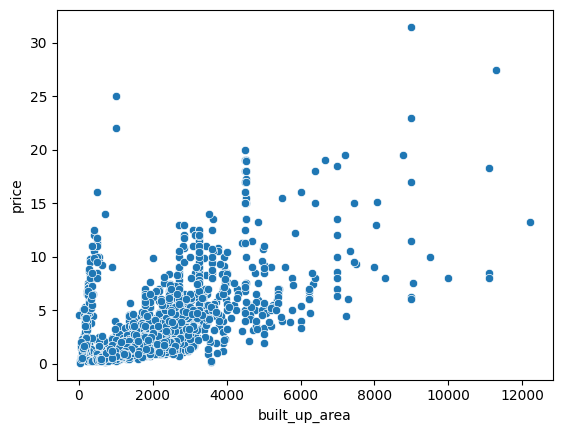

In [34]:
sns.scatterplot(x =df['built_up_area'],y = df['price'])

In [35]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [36]:
anamoly_df.head()

,price,area,built_up_area
4,3.98,2200.11,1991.0
38,3.40,2185.09,1977.0
59,10.00,4950.00,550.0
80,11.30,4500.00,480.0
94,6.80,2160.00,220.0


In [37]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [38]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

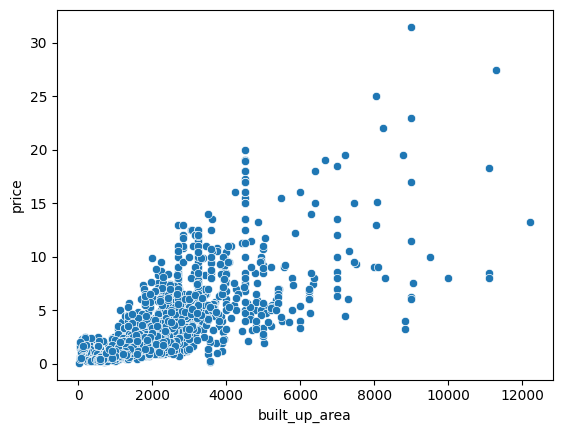

In [40]:
sns.scatterplot(x = df['built_up_area'],y = df['price'])

In [41]:
df = df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'])

In [42]:
df.head()

,society,price,sector,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,independent,15.50,sector 43,28233.0,5,6,3,3.0,East,Moderately Old,house,5490.00,1,1,1,1,0,0,76
1,trisara our homes 3,0.38,sohna road,6312.0,2,2,2,1.0,NaN,Undefined,flat,602.00,0,0,0,0,0,0,0
2,sare green parc phase 3,0.70,sector 92,5279.0,3,2,2,4.0,NaN,Relatively New,flat,1325.00,0,0,0,0,0,0,56
3,emaar gurgaon greens,1.60,sector 102,9696.0,3,3,3,8.0,NaN,Relatively New,flat,1315.00,0,0,0,0,0,0,46
4,emaar mgf the palm drive,3.98,sector 66,18090.0,3,4,3+,2.0,South-East,Moderately Old,flat,2200.11,0,1,0,0,0,2,123


In [43]:
df.isnull().sum()

society               1
price                 0
sector                0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             17
facing             1012
agePossession         0
property_type         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [44]:
df[df['floorNum'].isnull()]

,society,price,sector,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
121,vipul tatvam villa,8.50,sector 48,26235.0,4,4,2,NaN,East,Moderately Old,house,3240.0,0,1,1,1,0,0,88
152,experion heartsong,1.08,dwarka expressway,6150.0,3,3,0,NaN,NaN,Under Construction,flat,1758.0,0,0,0,0,0,0,0
243,independent,1.50,sector 3,10288.0,3,3,0,NaN,NaN,Old Property,house,210.0,0,0,0,0,0,0,0
803,independent,1.45,sector 24,2984.0,3,3,1,NaN,NaN,Old Property,house,540.0,0,0,0,0,0,0,9
980,dlf new town heights,2.47,sector 86,7719.0,4,4,3+,NaN,West,Moderately Old,house,2800.0,0,1,0,1,0,2,130
1229,independent,6.50,sector 7,15046.0,3,2,3+,NaN,NaN,Old Property,house,4320.0,0,0,0,0,0,0,9
1521,ansal sushant lok plots,3.30,sector 43,26570.0,1,1,0,NaN,NaN,Under Construction,house,1242.0,0,0,0,0,0,0,0
1524,NaN,0.60,sector 78,3692.0,2,2,0,NaN,NaN,Under Construction,flat,1625.0,0,0,0,0,0,0,0
1534,vipul tatvam villa,8.50,sector 48,26235.0,4,4,1,NaN,NaN,Relatively New,house,3240.0,0,0,0,0,0,0,21
1560,independent,5.60,sector 2,17284.0,8,6,3+,NaN,South-West,Moderately Old,house,3240.0,1,1,1,1,0,0,0


In [45]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [46]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_46564\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [47]:
df.isnull().sum()

society               1
price                 0
sector                0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1012
agePossession         0
property_type         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [48]:
1011/df.shape[0]

0.2843881856540084

<Axes: ylabel='count'>

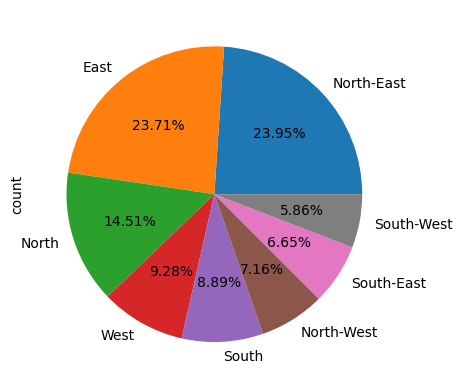

In [49]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [50]:
df = df.drop(columns=['facing'])

In [51]:
df.sample(5)

,society,price,sector,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2723,dlf city plots phase 3,6.50,sector 24,18571.0,4,5,3+,3.0,New Property,flat,3889.00,0,1,0,0,0,1,42
891,m3m merlin,2.65,sector 67,12945.0,3,3,3,0.0,Relatively New,flat,2047.12,0,0,0,0,1,2,174
1615,emaar palm gardens,1.30,sector 83,11868.0,3,3,3,16.0,Relatively New,flat,1387.00,0,1,0,0,0,2,174
1,trisara our homes 3,0.38,sohna road,6312.0,2,2,2,1.0,Undefined,flat,602.00,0,0,0,0,0,0,0
592,ats tourmaline,2.10,sector 109,8123.0,3,4,3+,11.0,Relatively New,flat,2100.00,0,1,0,0,0,2,165


In [52]:
df.isnull().sum()

society            1
price              0
sector             0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
property_type      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [54]:
df = df.drop(index = [1524])

In [55]:
df.isnull().sum()

society            0
price              0
sector             0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
property_type      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [56]:
df['agePossession'].value_counts()

agePossession
Relatively New        1604
New Property           557
Moderately Old         546
Old Property           293
Undefined              291
Under Construction     263
Name: count, dtype: int64

In [57]:
df[df['agePossession'] == 'Undefined']

,society,price,sector,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,property_type,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1,trisara our homes 3,0.38,sohna road,6312.0,2,2,2,1.0,Undefined,flat,602.0,0,0,0,0,0,0,0
27,laxmi pareena,0.30,sector 99a,6666.0,2,1,0,12.0,Undefined,flat,500.0,0,0,0,0,0,0,0
29,aipl zen residences,1.40,sector 70a,11094.0,2,2,2,16.0,Undefined,flat,1262.0,0,0,0,0,0,0,0
47,supertech araville,0.90,sector 79,6950.0,2,2,0,12.0,Undefined,flat,1295.0,0,0,0,0,0,0,0
58,ansal api esencia,1.20,sector 67,7407.0,3,3,2,1.0,Undefined,flat,200.0,0,0,0,0,0,0,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3502,m3m golfestate,1.40,sector 79,10000.0,2,2,2,4.0,Undefined,flat,1556.0,1,1,1,0,0,1,83
3523,godrej air,1.40,sector 85,10000.0,2,2,3,23.0,Undefined,flat,1400.0,0,0,0,0,0,0,44
3535,satya element one,0.94,sector 49,14009.0,1,2,2,2.0,Undefined,flat,746.0,0,0,0,0,0,0,0
3548,independent,0.74,sector 105,7400.0,3,3,0,2.0,Undefined,house,1000.0,0,0,0,0,0,0,0


In [58]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [59]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [60]:
df['agePossession'].value_counts()

agePossession
Relatively New        1716
New Property           597
Moderately Old         584
Old Property           326
Under Construction     277
Undefined               54
Name: count, dtype: int64

In [61]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [62]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [63]:
df['agePossession'].value_counts()

agePossession
Relatively New        1726
New Property           598
Moderately Old         591
Old Property           329
Under Construction     277
Undefined               33
Name: count, dtype: int64

In [64]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [65]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [66]:
df['agePossession'].value_counts()

agePossession
Relatively New        1728
Moderately Old         622
New Property           598
Old Property           329
Under Construction     277
Name: count, dtype: int64

In [67]:
df.isnull().sum()

society            0
price              0
sector             0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
property_type      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [68]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)